In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Loading dataset from: /content/drive/MyDrive/Colab Notebooks/extracted_features.csv


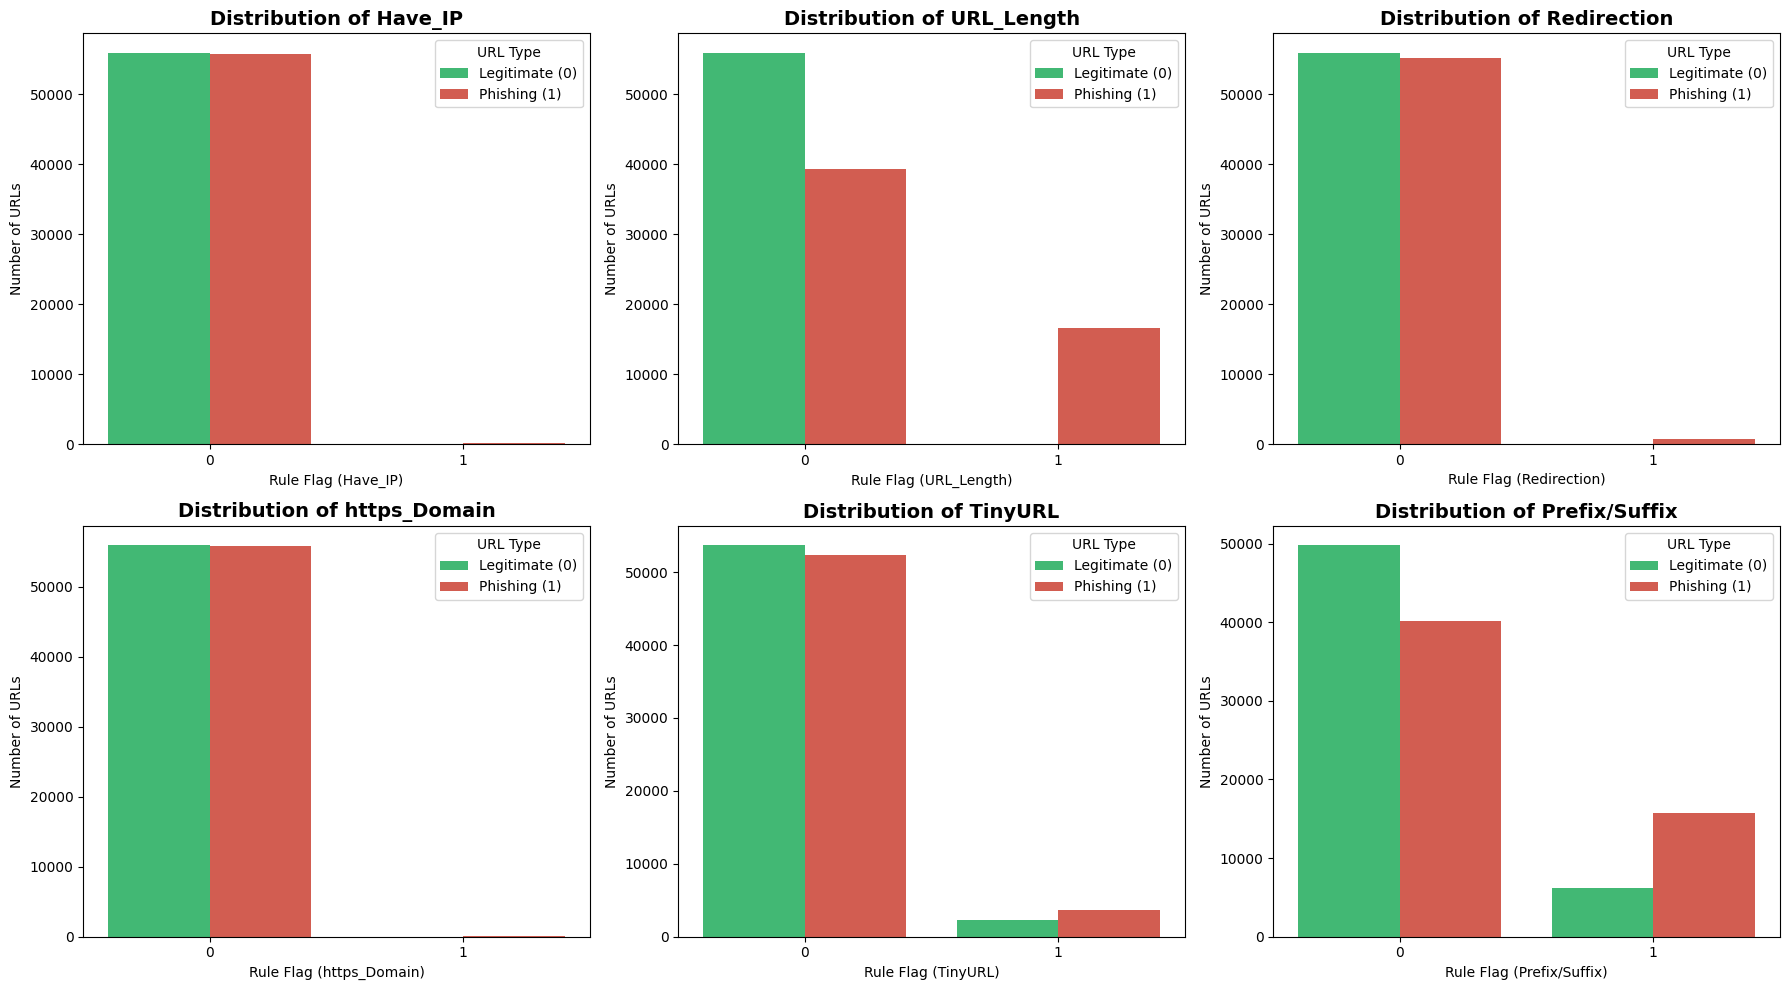

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_feature_distributions(csv_path):
    print(f"Loading dataset from: {csv_path}")
    df = pd.read_csv(csv_path)
    
    # Isolate just the 6 tabular rules (ignore the raw text and labels)
    features = [col for col in df.columns if col not in ['url', 'label']]
    
    # Create a 2x3 grid for our 6 graphs
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
    axes = axes.flatten()
    
    # Loop through each feature and rapidly draw a bar chart color-coded by the Answer Key!
    for i, feature in enumerate(features):
        sns.countplot(
            data=df, 
            x=feature, 
            hue='label', 
            palette={0: '#2ecc71', 1: '#e74c3c'}, # Bright Green vs Red
            ax=axes[i]
        )
        
        axes[i].set_title(f"Distribution of {feature}", fontsize=14, fontweight='bold')
        axes[i].set_xlabel(f"Rule Flag ({feature})")
        axes[i].set_ylabel("Number of URLs")
        
        # Override the ugly default [0, 1] legend with human words
        handles, _ = axes[i].get_legend_handles_labels()
        if handles:
            axes[i].legend(handles, ['Legitimate (0)', 'Phishing (1)'], title='URL Type')
            
    plt.tight_layout()
    plt.show()

# Run the visualization generator! 
# (Make sure to change the path if you uploaded it straight to the Colab root!)
plot_feature_distributions('/content/drive/MyDrive/Colab Notebooks/extracted_features.csv')


1. Loading the extracted features dataset...
2. Tokenizing URLs and merging with tabular features...
3. Splitting data into 70% Training and 30% Testing...
4. Building the 1D CNN Architecture with Character Embeddings...
5. Compiling the model (Adam Optimizer)..

--- STARTING TRAINING (50 Epochs) ---
Epoch 1/50
1958/1958 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - accuracy: 0.9883 - loss: 0.0449 - val_accuracy: 0.9960 - val_loss: 0.0172
Epoch 2/50
1958/1958 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9956 - loss: 0.0213 - val_accuracy: 0.9964 - val_loss: 0.0160
Epoch 3/50
1958/1958 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9962 - loss: 0.0190 - val_accuracy: 0.9945 - val_loss: 0.0322
Epoch 4/50
1958/1958 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9966 - loss: 0.0194 - val_accuracy: 0.9971 - val_loss: 0.0138
Epoch 5/50
1958/1958 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9969 - loss: 0.0166 - val_accuracy: 0.9964 - val_loss: 0.0162
Epoch 6/50
1958/1958 ━━━━━━━━━━━━━━━━━━━━ 9s 4

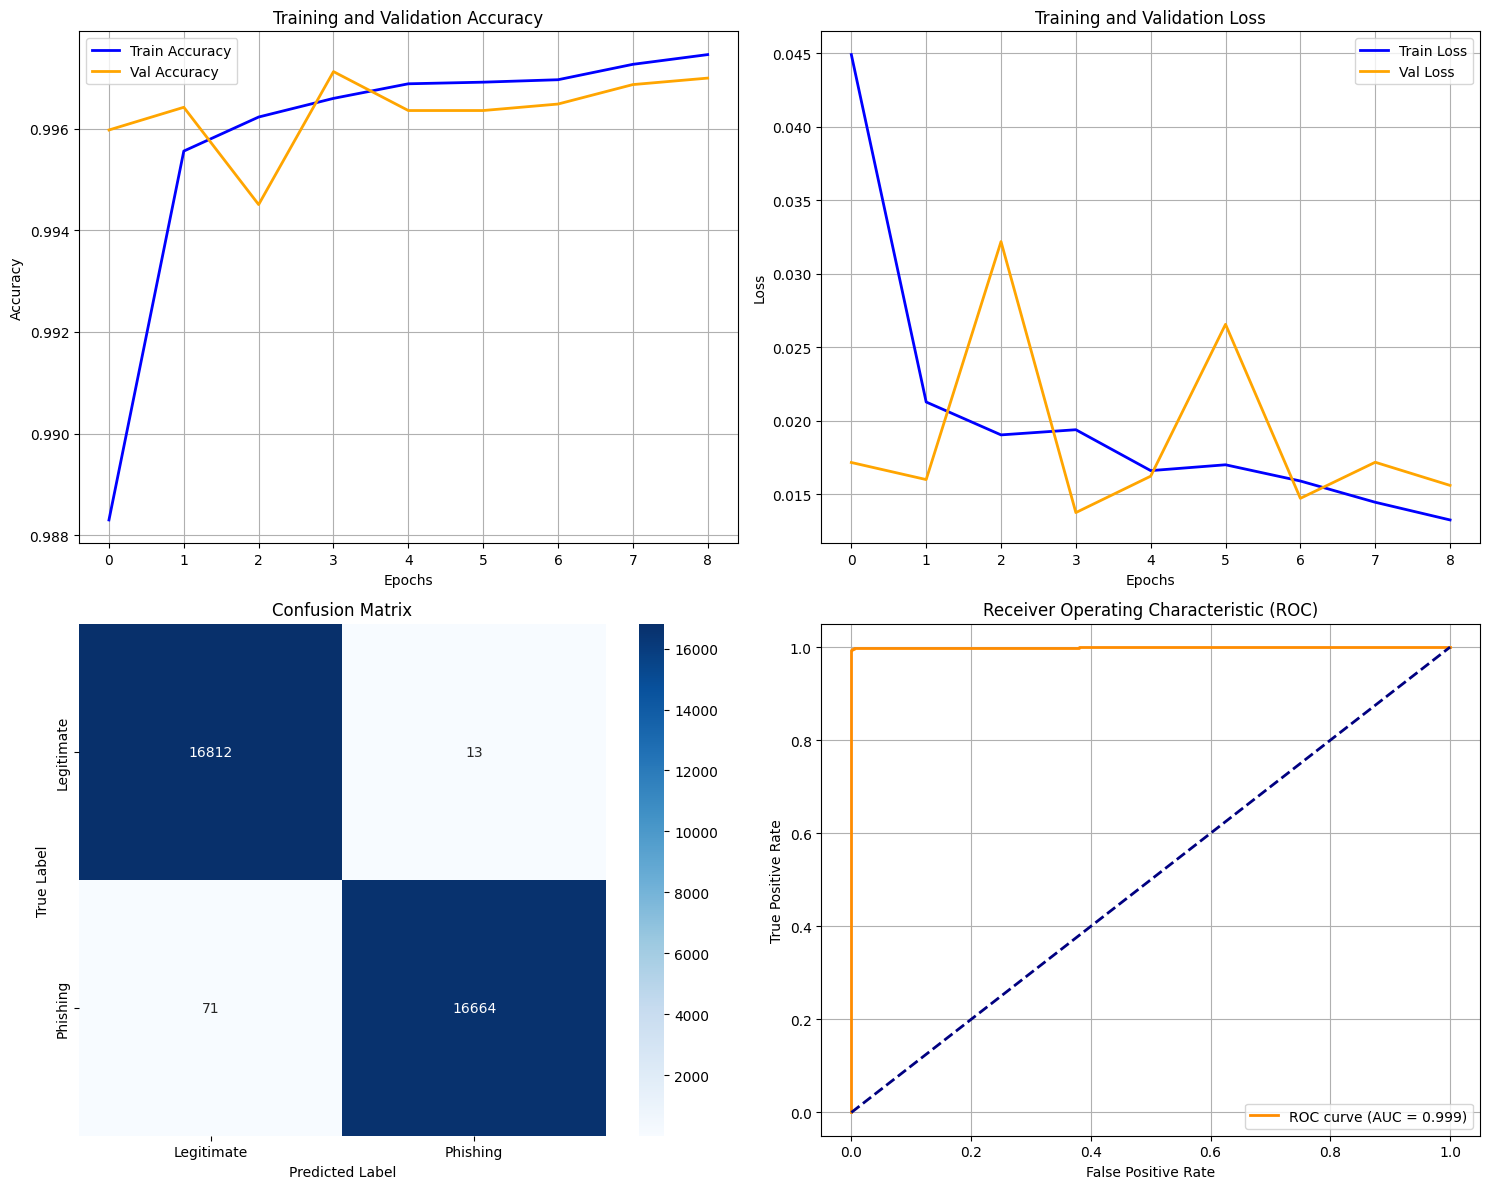

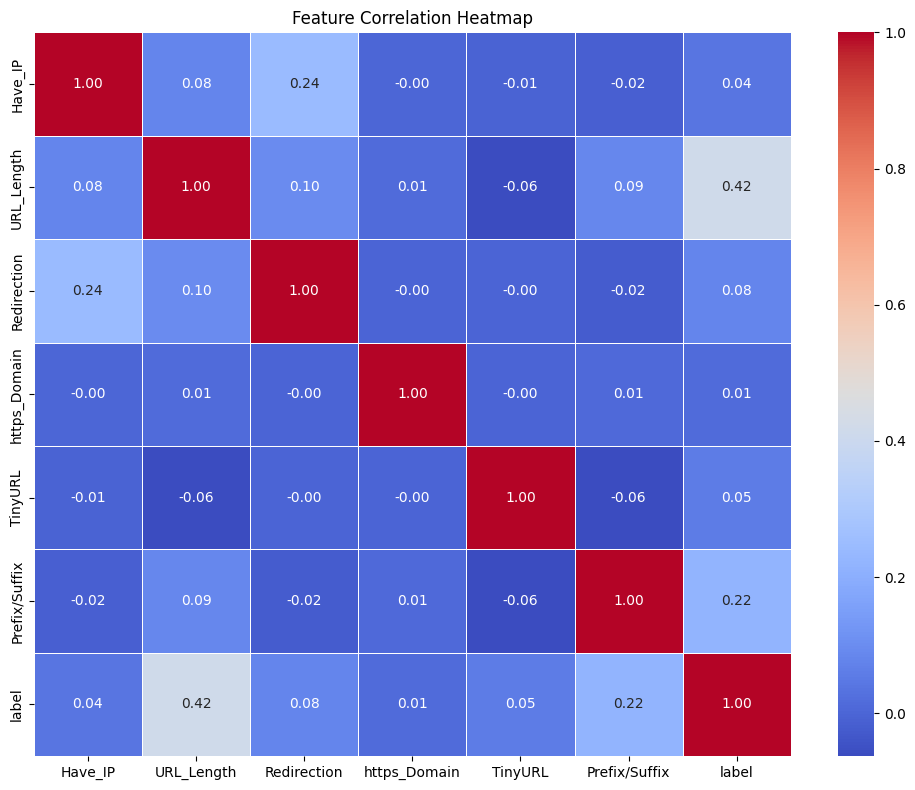

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, Dropout, Flatten, Dense, Embedding, MaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

def build_and_train_model():
    print("1. Loading the extracted features dataset...")
    data_path = '/content/drive/MyDrive/Colab Notebooks/extracted_features.csv'
    df = pd.read_csv(data_path)
    
    # Stage 4: Data Preprocessing & Merging
    print("2. Tokenizing URLs and merging with tabular features...")
    y = df['label'].values
    
    # Extract Tabular Features (all columns except url and label)
    tabular_cols = [c for c in df.columns if c not in ['url', 'label']]
    X_tabular = df[tabular_cols].values
    
    # Extract and Tokenize URLs
    urls = df['url'].astype(str).tolist()
    MAX_LEN = 150
    tokenizer = Tokenizer(char_level=True)
    tokenizer.fit_on_texts(urls)
    X_sequences = tokenizer.texts_to_sequences(urls)
    X_sequences = pad_sequences(X_sequences, maxlen=MAX_LEN, padding='post')
    
    # The Sequential Merge: 6 numerical rules + 150 character IDs = 156 integers per URL
    X_combined = np.hstack([X_tabular, X_sequences])
    
    print("3. Splitting data into 70% Training and 30% Testing...")
    X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.30, random_state=42)
    
    # Calculate vocabulary size for the Embedding Layer
    vocab_size = len(tokenizer.word_index) + 5
    
    # Stage 5: Model Architecture
    print("4. Building the 1D CNN Architecture with Character Embeddings...")
    model = Sequential()
    
    model.add(Input(shape=(X_train.shape[1],)))
    # The crucial Embedding Layer: Maps all 156 integers into dense vectors of shape 32
    model.add(Embedding(input_dim=vocab_size, output_dim=32))
    
    # Block 1
    model.add(Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.2))
    
    # Block 2
    model.add(Conv1D(filters=256, kernel_size=3, activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.5))
    
    # Flatten & Dense Layers
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))
    
    # Output Layer
    model.add(Dense(1, activation='sigmoid'))
    
    # Stage 6: Model Training
    print("5. Compiling the model (Adam Optimizer)..")
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    print("\n--- STARTING TRAINING (50 Epochs) ---")
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=1 
    )
    
    # Save the trained brain
    os.makedirs('../models/', exist_ok=True)
    model.save('../models/phishing_cnn_model.keras')
    print("\nModel saved to '../models/phishing_cnn_model.keras'")
    
    # Stage 7: Evaluation
    print("\n6. Evaluating on the hidden 30% Testing Data...")
    predictions_prob = model.predict(X_test)
    predictions = (predictions_prob > 0.50).astype(int)
    
    print("\n--- CONFUSION MATRIX ---")
    cm = confusion_matrix(y_test, predictions)
    print(cm)
    print(f"True Negatives: {cm[0][0]} | False Positives: {cm[0][1]}")
    print(f"False Negatives: {cm[1][0]} | True Positives: {cm[1][1]}")
    
    print("\n--- FINAL REPORT CARD ---")
    print(classification_report(y_test, predictions, target_names=['Legitimate (0)', 'Phishing (1)']))
    
    print("\n7. Generating Visualizations...")
    plot_metrics(history, cm, y_test, predictions_prob, df)

def plot_metrics(history, cm, y_test, predictions_prob, df):
    print("Plotting Performance Dashboards...")
    plt.figure(figsize=(15, 12))
    
    # 1. Training & Validation Accuracy
    plt.subplot(2, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue', lw=2)
    plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange', lw=2)
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # 2. Training & Validation Loss
    plt.subplot(2, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss', color='blue', lw=2)
    plt.plot(history.history['val_loss'], label='Val Loss', color='orange', lw=2)
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # 3. Confusion Matrix Heatmap
    plt.subplot(2, 2, 3)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Legitimate', 'Phishing'], 
                yticklabels=['Legitimate', 'Phishing'])
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

    # 4. ROC Curve
    plt.subplot(2, 2, 4)
    fpr, tpr, _ = roc_curve(y_test, predictions_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc="lower right")
    plt.grid(True)
    
    plt.tight_layout()
    os.makedirs('../models/', exist_ok=True)
    plt.savefig('../models/metrics_dashboard.png')
    plt.show()

    # 5. Feature Correlation Heatmap (Seperate Figure)
    plt.figure(figsize=(10, 8))
    tabular_cols = [c for c in df.columns if c not in ['url']] # Include 'label' to see correlation with outcome
    corr = df[tabular_cols].corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
    plt.title('Feature Correlation Heatmap')
    plt.tight_layout()
    plt.savefig('../models/feature_heatmap.png')
    plt.show()

if __name__ == "__main__":
    build_and_train_model()